In [2]:
import os
import torch
import torchvision
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor, Resize, Compose
from torch.utils.data import random_split, DataLoader
from torchvision.utils import make_grid
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import time

In [3]:
from google.colab import files

# 1. Upload your kaggle.json file
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Check if the file was uploaded successfully
if 'kaggle.json' not in uploaded:
    print("kaggle.json not found. Please run the cell again and upload the file.")
else:
    # 2. Create the .kaggle directory and move the file there
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/

    # 3. Set permissions (important!)
    !chmod 600 ~/.kaggle/kaggle.json

    print("Kaggle API token configured successfully.")

Please upload your kaggle.json file:


Saving dataset.zip to dataset.zip
kaggle.json not found. Please run the cell again and upload the file.


In [4]:
# The downloaded file is typically named dataset-slug.zip
!unzip -q /content/dataset.zip
# Use -q for quieter output. Remove it if you want to see the files being unzipped.

In [5]:
transform = Compose([Resize((64, 64)), ToTensor()])
dataset = ImageFolder('/content/dataset', transform=transform)
print(dataset.classes)

['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


In [6]:
random_seed = 42
torch.manual_seed(random_seed)
val_size = 1000
test_size = 1000
train_size = len(dataset) - val_size - test_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

In [7]:
batch_size = 128
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_dl = DataLoader(val_ds, batch_size * 2, num_workers=4, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


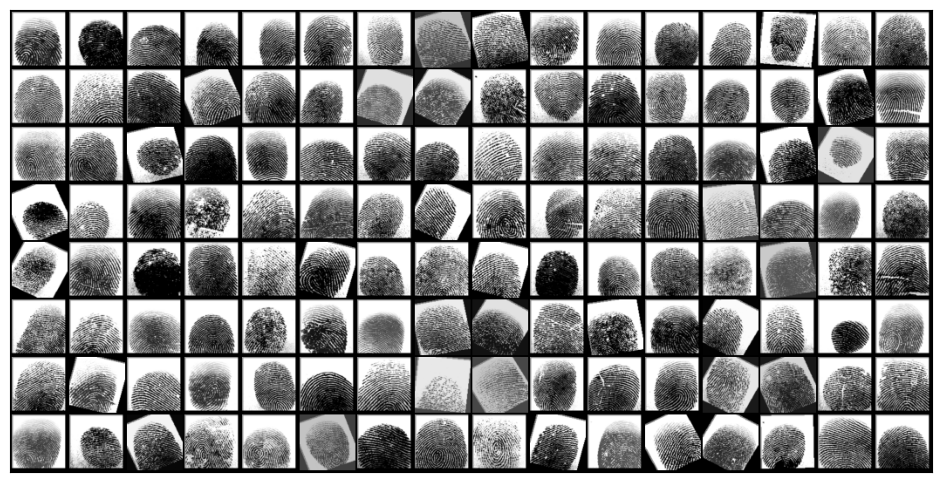

In [8]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break
show_batch(train_dl)

In [9]:
# Base class for model
class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return loss, acc

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result, train_loss, train_acc):
        print(f"Epoch [{epoch+1}], train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
              f"val_loss: {result['val_loss']:.4f}, val_acc: {result['val_acc']:.4f}")

def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [10]:
# CNN model
class FingerprintToBloodGroup(ImageClassificationBase):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

In [11]:
def get_default_device():
    return torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

In [12]:
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        return len(self.dl)

In [13]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

In [14]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.Adam):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': []}
    optimizer = opt_func(model.parameters(), lr)

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_losses, train_accs = [], []

        for batch in train_loader:
            loss, acc = model.training_step(batch)
            train_losses.append(loss.item())
            train_accs.append(acc.item())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        result = evaluate(model, val_loader)
        epoch_time = time.time() - start_time

        train_loss = np.mean(train_losses)
        train_acc = np.mean(train_accs)

        model.epoch_end(epoch, result, train_loss, train_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(result['val_loss'])
        history['val_acc'].append(result['val_acc'])
        history['epoch_time'].append(epoch_time)

    return history

In [15]:
@torch.no_grad()
def evaluate_with_predictions(model, val_loader, return_probs=False):
    model.eval()
    predictions, targets, probabilities = [], [], []

    for batch in val_loader:
        images, labels = batch
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, dim=1)

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.cpu().numpy())
        probabilities.extend(probs.cpu().numpy())

    if return_probs:
        return np.array(predictions), np.array(targets), np.array(probabilities)
    return np.array(predictions), np.array(targets)


In [16]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Epoch time plot
    axes[1, 0].plot(epochs, history['epoch_time'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Time (seconds)', fontsize=12)
    axes[1, 0].set_title('Training Time per Epoch', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Loss vs Accuracy scatter
    axes[1, 1].scatter(history['val_loss'], history['val_acc'], c=epochs, cmap='viridis', s=100)
    axes[1, 1].set_xlabel('Validation Loss', fontsize=12)
    axes[1, 1].set_ylabel('Validation Accuracy', fontsize=12)
    axes[1, 1].set_title('Loss vs Accuracy Progression', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
    cbar.set_label('Epoch', fontsize=10)

    plt.tight_layout()
    plt.show()


In [17]:
def plot_confusion_matrix(targets, predictions, class_names):
    """Plot confusion matrix with detailed annotations"""
    cm = confusion_matrix(targets, predictions)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
                yticklabels=class_names, cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Percentage'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [18]:
def plot_per_class_metrics(targets, predictions, class_names):
    """Plot per-class precision, recall, and F1-score"""
    precision, recall, f1, support = precision_recall_fscore_support(targets, predictions)

    x = np.arange(len(class_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
    ax.bar(x, recall, width, label='Recall', alpha=0.8)
    ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

    ax.set_xlabel('Blood Group', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])

    plt.tight_layout()
    plt.show()


In [19]:
def plot_roc_curves(targets, probabilities, class_names):
    """Plot ROC curves for multi-class classification"""
    n_classes = len(class_names)
    targets_bin = label_binarize(targets, classes=range(n_classes))

    fpr, tpr, roc_auc = {}, {}, {}

    plt.figure(figsize=(12, 8))
    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(targets_bin[:, i], probabilities[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Multi-Class Classification', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [20]:
def visualize_predictions(model, val_loader, class_names, num_images=6):
    """Visualize predictions with confidence scores"""
    model.eval()
    images, labels = next(iter(val_loader))
    images, labels = images[:num_images], labels[:num_images]
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min())  # Normalize for display

        axes[i].imshow(img)
        correct = preds[i] == labels[i]
        color = 'green' if correct else 'red'
        axes[i].set_title(f"True: {class_names[labels[i]]}\n"
                         f"Pred: {class_names[preds[i]]}\n"
                         f"Confidence: {confidences[i]:.2%}",
                         color=color, fontweight='bold')
        axes[i].axis('off')
        axes[i].spines['top'].set_visible(True)
        axes[i].spines['right'].set_visible(True)
        axes[i].spines['bottom'].set_visible(True)
        axes[i].spines['left'].set_visible(True)
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

    plt.tight_layout()
    plt.show()


In [21]:
def print_summary_metrics(targets, predictions, class_names):
    """Print comprehensive summary metrics"""
    from sklearn.metrics import accuracy_score, balanced_accuracy_score

    print("\n" + "="*60)
    print("PERFORMANCE SUMMARY")
    print("="*60)
    print(f"Overall Accuracy: {accuracy_score(targets, predictions):.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy_score(targets, predictions):.4f}")
    print("\n" + "-"*60)
    print("Classification Report:")
    print("-"*60)
    print(classification_report(targets, predictions, target_names=class_names, digits=4))


In [22]:
# ============= MAIN TRAINING CODE =============
device = get_default_device()
print(f"Using device: {device}")

# Initialize model
model = FingerprintToBloodGroup(num_classes=len(dataset.classes))
model = to_device(model, device)

train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)

# Training
num_epochs = 20
lr = 0.001

print("\nStarting training...")
history = fit(num_epochs, lr, model, train_dl, val_dl)

Using device: cuda

Starting training...
Epoch [1], train_loss: 2.0799, train_acc: 0.1297, val_loss: 2.0575, val_acc: 0.1971
Epoch [2], train_loss: 1.7335, train_acc: 0.3236, val_loss: 1.4911, val_acc: 0.3896
Epoch [3], train_loss: 1.4350, train_acc: 0.4276, val_loss: 1.3510, val_acc: 0.4800
Epoch [4], train_loss: 1.1879, train_acc: 0.5488, val_loss: 1.0135, val_acc: 0.6159
Epoch [5], train_loss: 0.9447, train_acc: 0.6472, val_loss: 1.0186, val_acc: 0.6479
Epoch [6], train_loss: 0.7651, train_acc: 0.7172, val_loss: 0.7306, val_acc: 0.7280
Epoch [7], train_loss: 0.6317, train_acc: 0.7596, val_loss: 0.6161, val_acc: 0.7795
Epoch [8], train_loss: 0.5232, train_acc: 0.8054, val_loss: 0.5394, val_acc: 0.7986
Epoch [9], train_loss: 0.4633, train_acc: 0.8229, val_loss: 0.5526, val_acc: 0.8163
Epoch [10], train_loss: 0.4020, train_acc: 0.8494, val_loss: 0.4694, val_acc: 0.8303
Epoch [11], train_loss: 0.3789, train_acc: 0.8546, val_loss: 0.4122, val_acc: 0.8480
Epoch [12], train_loss: 0.3129, t


Generating performance visualizations...


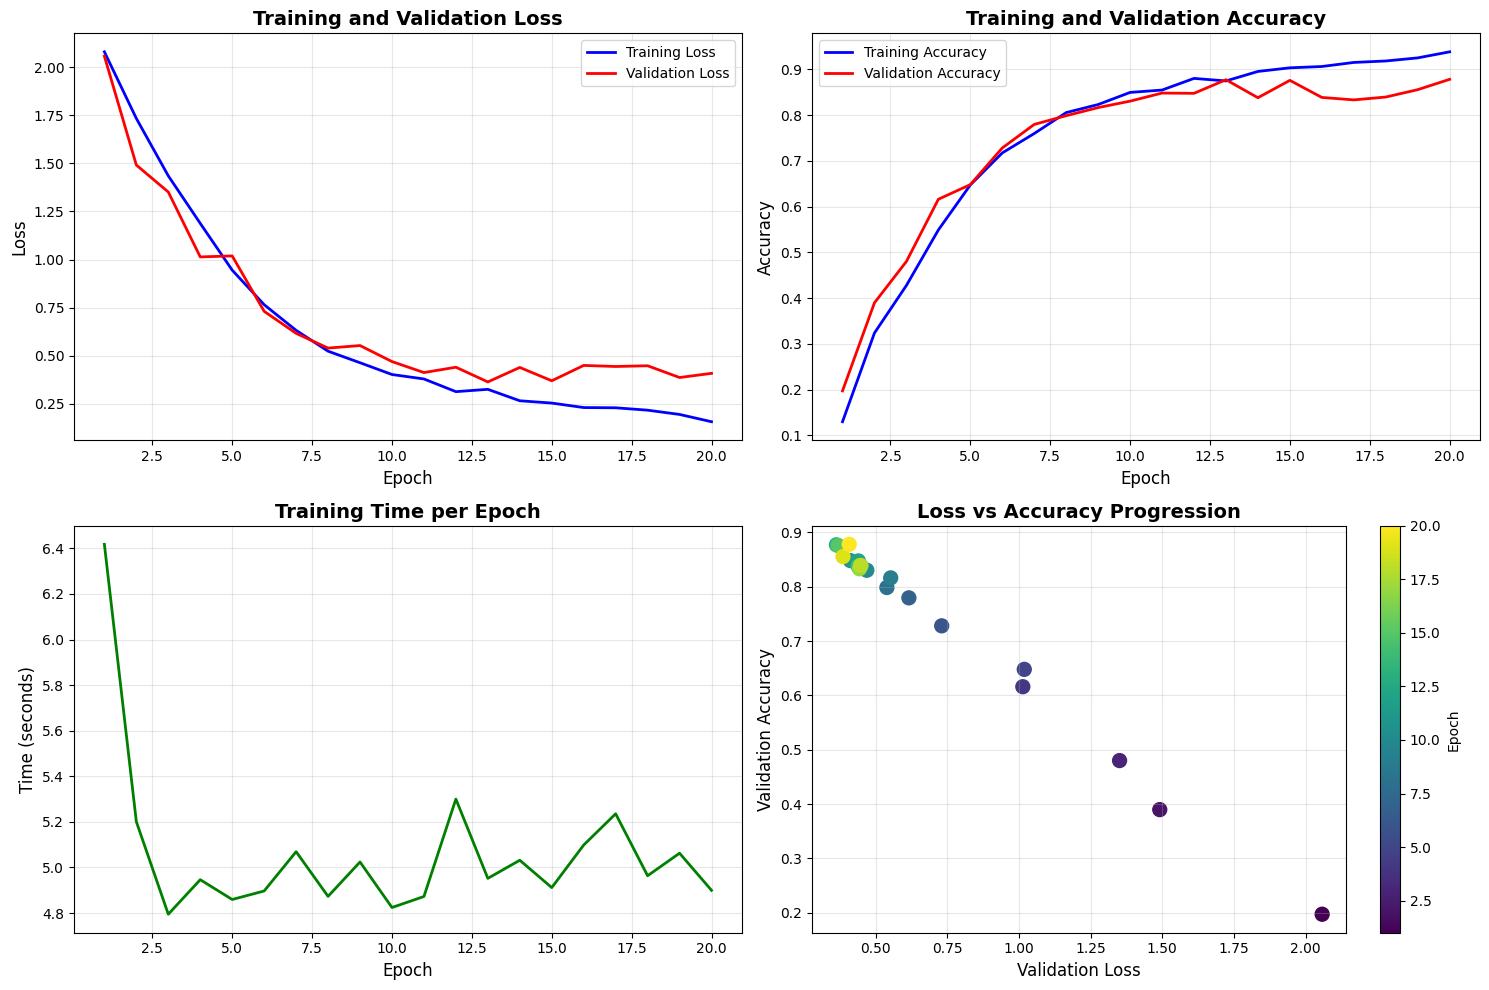


PERFORMANCE SUMMARY
Overall Accuracy: 0.8780
Balanced Accuracy: 0.8760

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

          A+     0.9083    0.8684    0.8879       114
          A-     0.8533    0.8889    0.8707       144
         AB+     0.8819    0.9407    0.9104       135
         AB-     0.8618    0.8689    0.8653       122
          B+     0.9204    0.8889    0.9043       117
          B-     0.9143    0.8951    0.9046       143
          O+     0.7752    0.9091    0.8368       110
          O-     0.9348    0.7478    0.8309       115

    accuracy                         0.8780      1000
   macro avg     0.8812    0.8760    0.8764      1000
weighted avg     0.8818    0.8780    0.8778      1000



In [23]:
# Plot training history
print("\nGenerating performance visualizations...")
plot_training_history(history)

# Evaluate with predictions and probabilities
predictions, targets, probabilities = evaluate_with_predictions(model, val_dl, return_probs=True)

# Print summary metrics
print_summary_metrics(targets, predictions, dataset.classes)

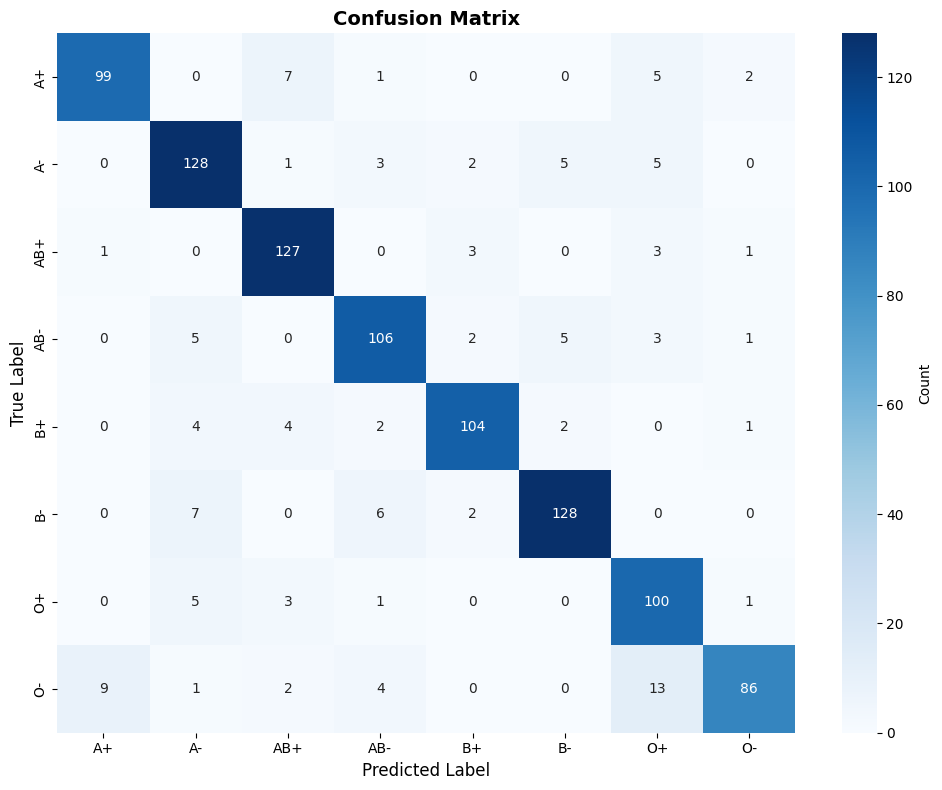

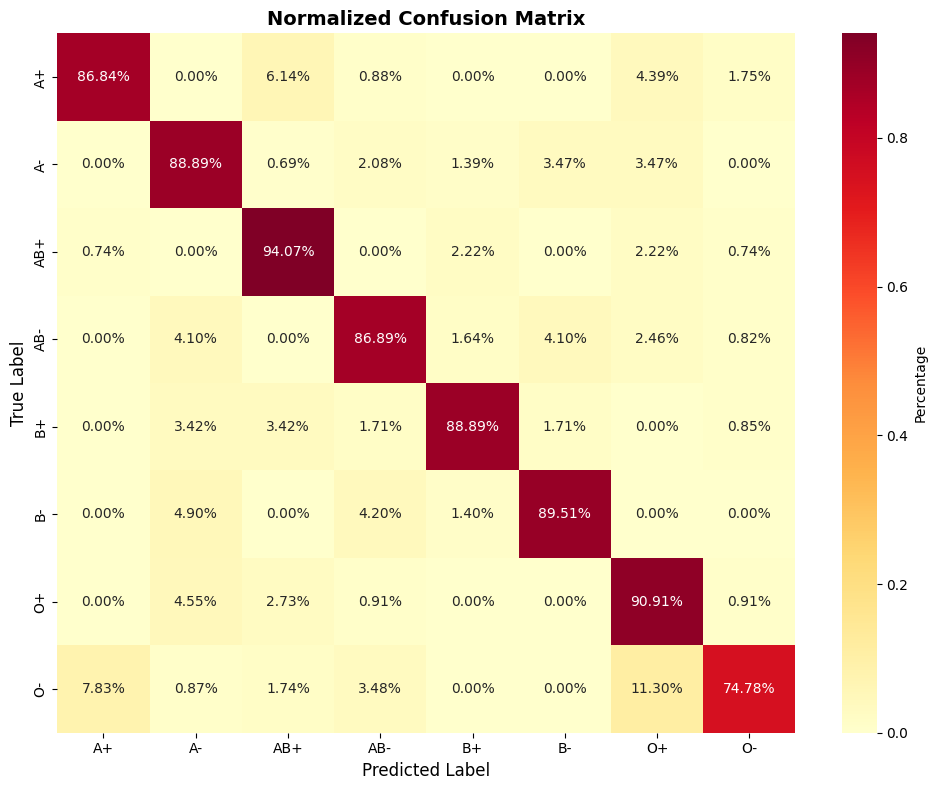

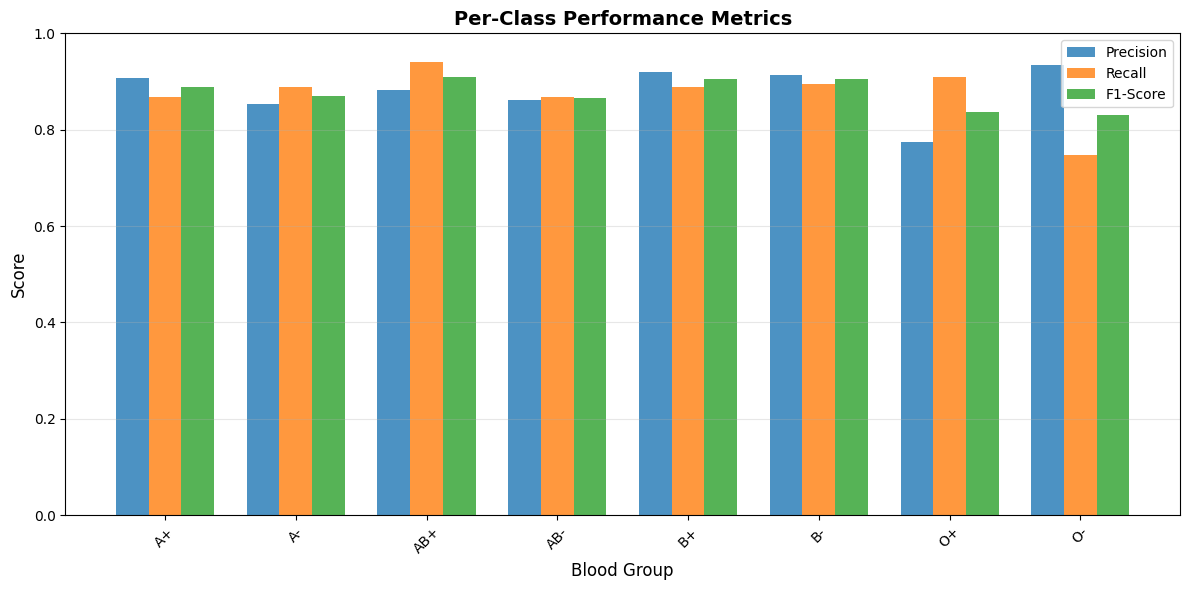

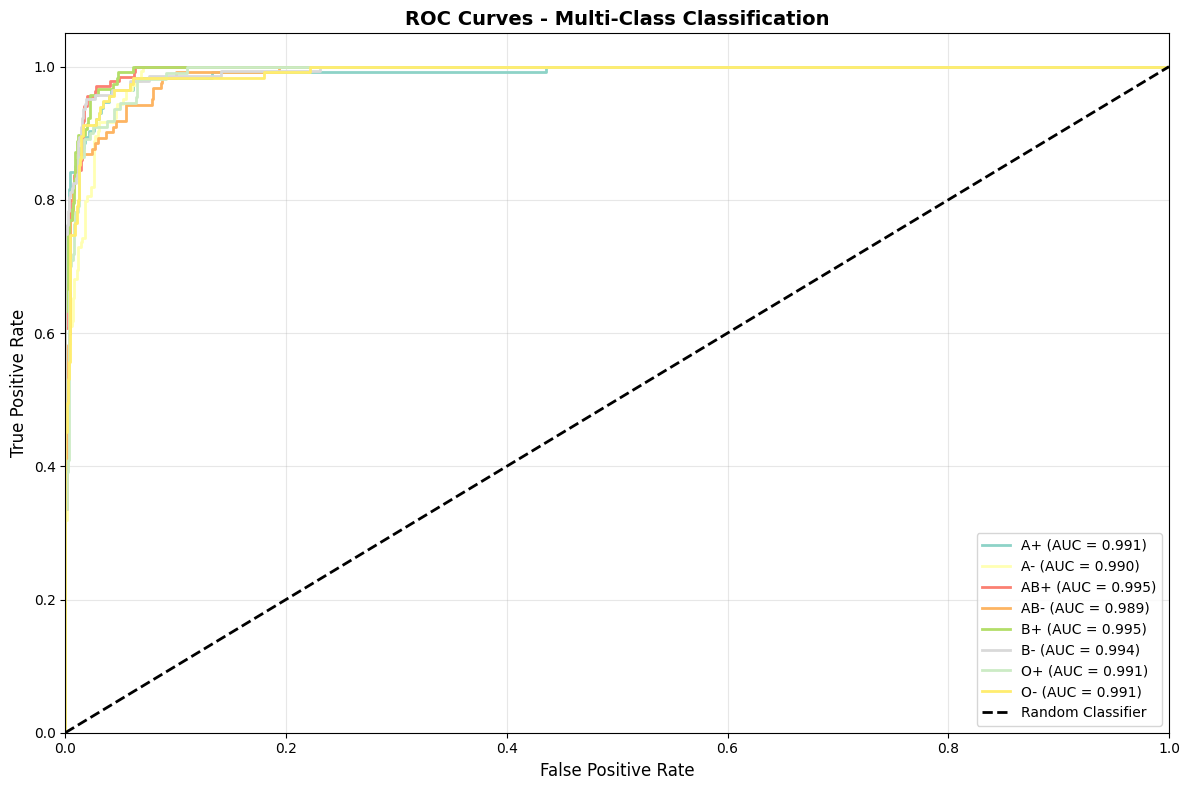

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


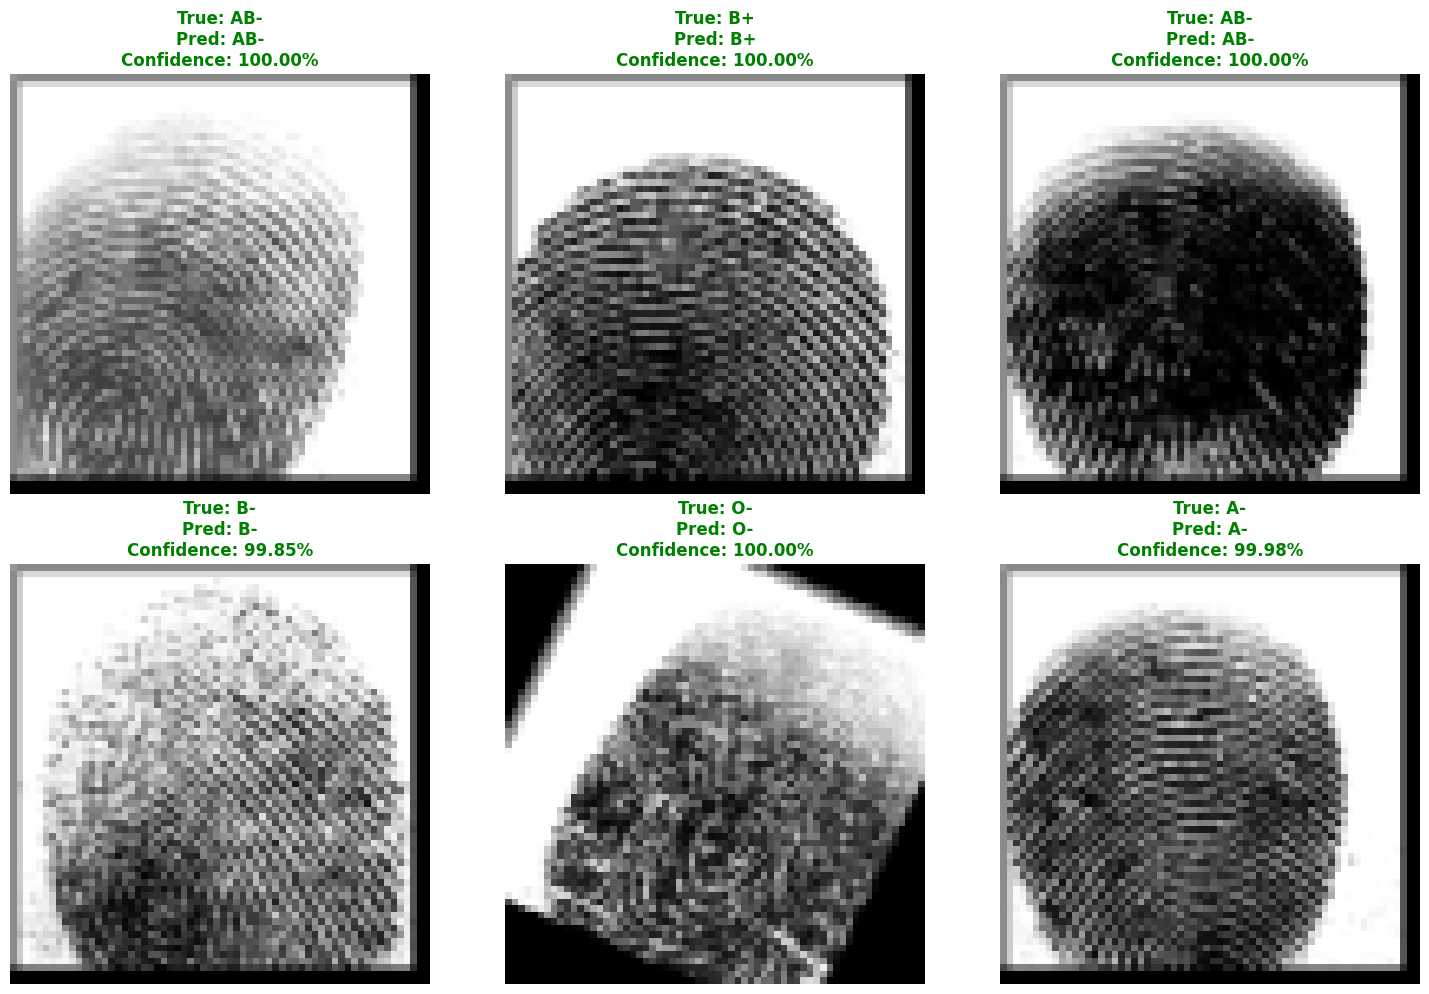


Training and evaluation complete!


In [24]:
# Plot confusion matrices
plot_confusion_matrix(targets, predictions, dataset.classes)

# Plot per-class metrics
plot_per_class_metrics(targets, predictions, dataset.classes)

# Plot ROC curves
plot_roc_curves(targets, probabilities, dataset.classes)

# Visualize sample predictions
visualize_predictions(model, val_dl, dataset.classes, num_images=6)

print("\nTraining and evaluation complete!")

In [25]:
# ============= MODEL SAVING =============
def save_model(model, history, predictions, targets, save_dir='model_checkpoints'):
    """Save model weights, architecture, and training results"""
    import os
    import json
    from datetime import datetime

    # Create save directory
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # Save model state dict (weights)
    model_path = os.path.join(save_dir, f'fingerprint_model_{timestamp}.pth')
    torch.save(model.state_dict(), model_path)
    print(f"\n✓ Model weights saved: {model_path}")

    # Save complete model (architecture + weights)
    complete_model_path = os.path.join(save_dir, f'fingerprint_model_complete_{timestamp}.pth')
    torch.save(model, complete_model_path)
    print(f"✓ Complete model saved: {complete_model_path}")

    # Save training history
    history_path = os.path.join(save_dir, f'training_history_{timestamp}.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=4)
    print(f"✓ Training history saved: {history_path}")

    # Save model configuration
    config = {
        'timestamp': timestamp,
        'num_epochs': len(history['train_loss']),
        'final_train_loss': history['train_loss'][-1],
        'final_train_acc': history['train_acc'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc': max(history['val_acc']),
        'best_epoch': history['val_acc'].index(max(history['val_acc'])) + 1,
        'total_training_time': sum(history['epoch_time']),
        'num_classes': len(dataset.classes),
        'class_names': dataset.classes,
        'device': str(device)
    }
    config_path = os.path.join(save_dir, f'model_config_{timestamp}.json')
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
    print(f"✓ Model configuration saved: {config_path}")

    # Save predictions and targets for later analysis
    results_path = os.path.join(save_dir, f'evaluation_results_{timestamp}.npz')
    np.savez(results_path, predictions=predictions, targets=targets,
             probabilities=probabilities if 'probabilities' in locals() else None)
    print(f"✓ Evaluation results saved: {results_path}")

    print(f"\n{'='*60}")
    print(f"All files saved in: {save_dir}/")
    print(f"{'='*60}")

    return model_path, config

In [26]:
def load_model(model_path, num_classes, device=None):
    """Load a saved model"""
    if device is None:
        device = get_default_device()

    # Initialize model architecture
    model = FingerprintToBloodGroup(num_classes=num_classes)

    # Load weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = to_device(model, device)
    model.eval()

    print(f"✓ Model loaded from: {model_path}")
    return model

In [27]:
save_model(model, history, predictions, targets)
print("\n✓ Model saving complete!")


✓ Model weights saved: model_checkpoints/fingerprint_model_20251013_170610.pth
✓ Complete model saved: model_checkpoints/fingerprint_model_complete_20251013_170610.pth
✓ Training history saved: model_checkpoints/training_history_20251013_170610.json
✓ Model configuration saved: model_checkpoints/model_config_20251013_170610.json
✓ Evaluation results saved: model_checkpoints/evaluation_results_20251013_170610.npz

All files saved in: model_checkpoints/

✓ Model saving complete!
